# NB08: Natural paired pyroxenes and two-pyroxene cross-mineral benchmark (v6)

## Purpose
Validate the opx ML thermobarometer on natural paired-pyroxene samples by
comparing it independently-calibrated cpx ML (Jorgenson 2022) and the classical
two-pyroxene solvus method (Putirka 2008 eq 36/39). Agreement between
independently trained methods on the same natural sample constitutes
cross-mineral validation without requiring experimental ground truth.

## Pipeline position
NB07 (uncertainty) -> **NB08** -> NB09 (manuscript diagnostics)

## Inputs
- `data/raw/external/LEPR_Wet_Stitched_April2023_Norm100Anhydrs.xlsx`
  (paired cpx + opx with experimental ground truth P, T)
- `data/external/thermobar_examples/Thermobar/docs/Examples/Two_Pyroxene_Thermobarometry/AllMatches.xlsx`
  (natural paired pyroxene, NO ground truth)
- canonical opx-only RF (`models/model_RF_*_opx_only_pwlr.joblib`)
- Jorgenson 2022 cpx-only RF via `Thermobar_onnx`
- Putirka 2008 eq36/39 via `Thermobar`

## Outputs
- `results/nb08_natural_predictions.csv`
- `results/nb08_cross_mineral_agreement.csv`
- `figures/fig_nb08_twopx_1to1.{png,pdf}`
- `figures/fig_nb08_disagreement_map.{png,pdf}`
- `figures/fig_nb08_geotherm.{png,pdf}`

## Canonical decisions locked here
- Disequilibrium index: DeltaP_(opx - cpx) in kbar
- Equilibrium flag: |DeltaP| < 2*sigma_conformal(P) AND |DeltaT| < 2*sigma_conformal(T)
- Sigma_conformal pulled from `results/nb07_conformal_qhat.json` (alpha=0.10 primary)

## Runtime
~5 min on laptop.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings('ignore')

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import ROOT, MODELS, RESULTS, FIGURES, LEPR_XLSX, SEED_MODEL
from src.features import build_feature_matrix
from src.plot_style import (
    apply_style, OKABE_ITO, PUTIRKA_COLOR, ML_COLOR, load_winning_config,
    canonical_model_filename,
)
from src.external_models import predict_jorgenson

apply_style()
print('NB08 v6 imports OK')


NB08 v6 imports OK


In [2]:
# Section 1. LEPR merged cpx + opx experiments (ground truth P, T available).
xls = pd.ExcelFile(LEPR_XLSX)
cpx = pd.read_excel(xls, sheet_name='Cpx').drop_duplicates('Experiment')
opx = pd.read_excel(xls, sheet_name='Opx').drop_duplicates('Experiment')
liq = pd.read_excel(xls, sheet_name='Liq').drop_duplicates('Experiment')

# Numeric coercion for all oxide columns (LEPR has string placeholders).
def _num(df, suf):
    for c in df.columns:
        if c.endswith(suf):
            df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0.0)
    return df
cpx = _num(cpx, '_Cpx'); opx = _num(opx, '_Opx'); liq = _num(liq, '_Liq')

# Merge on Experiment (inner) to keep only coexisting cpx + opx pairs.
lepr = cpx.merge(opx, on='Experiment', how='inner', suffixes=('_cpx', '_opx'))
# Ground-truth columns may be suffixed after merge.
for tgt in ['T_K', 'P_kbar']:
    for src in [tgt, f'{tgt}_cpx', f'{tgt}_opx']:
        if src in lepr.columns and tgt not in lepr.columns:
            lepr[tgt] = pd.to_numeric(lepr[src], errors='coerce')
lepr['T_C']    = lepr['T_K'] - 273.15
lepr = lepr[np.isfinite(lepr['T_C']) & np.isfinite(lepr['P_kbar'])
            & lepr['T_C'].between(400, 1900)
            & lepr['P_kbar'].between(-2, 100)].reset_index(drop=True)

print(f'LEPR paired cpx+opx with ground truth: n={len(lepr)}')

# Natural dataset (no ground truth). Use AllMatches.xlsx (437 rows).
tbar_path = ROOT / ('data/external/thermobar_examples/Thermobar/docs/Examples/'
                    'Two_Pyroxene_Thermobarometry/AllMatches.xlsx')
if tbar_path.exists():
    nat = pd.read_excel(tbar_path)
    for c in nat.columns:
        if c.endswith('_Cpx') or c.endswith('_Opx'):
            nat[c] = pd.to_numeric(nat[c], errors='coerce').fillna(0.0)
    nat = nat.reset_index(drop=True)
    print(f'Thermobar AllMatches natural set: n={len(nat)}')
else:
    nat = pd.DataFrame()
    print('Thermobar AllMatches not found, skipping natural dataset.')


LEPR paired cpx+opx with ground truth: n=327


Thermobar AllMatches natural set: n=437


In [3]:
# Section 2. Run our opx-only ML and Jorgenson cpx-only ML on both datasets.

config_3r = load_winning_config(RESULTS)
WIN_FEAT = config_3r['global_feature_set']

# Load canonical opx-only models.
m_T = joblib.load(MODELS / canonical_model_filename('RF', 'T_C',    'opx_only', RESULTS))
m_P = joblib.load(MODELS / canonical_model_filename('RF', 'P_kbar', 'opx_only', RESULTS))


def _opx_df_for_feats(df, suffix='_Opx'):
    '''Translate Thermobar/LEPR _Opx columns into the oxide names the feature
    builder expects (SiO2, TiO2, ..., Mg_num, En_frac, Fs_frac, Wo_frac,
    Al_IV, Al_VI, MgTs plus _cat columns).'''
    out = pd.DataFrame({
        'SiO2':      df.get(f'SiO2{suffix}',  0.0),
        'TiO2':      df.get(f'TiO2{suffix}',  0.0),
        'Al2O3':     df.get(f'Al2O3{suffix}', 0.0),
        'Cr2O3':     df.get(f'Cr2O3{suffix}', 0.0),
        'FeO_total': df.get(f'FeOt{suffix}',  0.0),
        'MnO':       df.get(f'MnO{suffix}',   0.0),
        'MgO':       df.get(f'MgO{suffix}',   0.0),
        'CaO':       df.get(f'CaO{suffix}',   0.0),
        'Na2O':      df.get(f'Na2O{suffix}',  0.0),
    })
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors='coerce').fillna(0.0)
    mg  = out['MgO'] / 40.304
    fe  = out['FeO_total'] / 71.844
    ca  = out['CaO'] / 56.077
    si  = out['SiO2'] / 60.084
    al  = out['Al2O3'] / 101.961
    tot = (mg + fe + ca).replace(0, np.nan)
    out['En_frac'] = 100 * mg / tot
    out['Fs_frac'] = 100 * fe / tot
    out['Wo_frac'] = 100 * ca / tot
    out['Mg_num']  = 100 * mg / (mg + fe).replace(0, np.nan)
    out['Al_IV']   = (2.0 - si * 2).clip(lower=0)
    out['Al_VI']   = (al * 2 - out['Al_IV']).clip(lower=0)
    out['MgTs']    = np.minimum(out['Al_IV'], out['Al_VI']).clip(lower=0)
    for c in ['SiO2_cat', 'TiO2_cat', 'Al2O3_cat', 'Cr2O3_cat',
              'FeO_cat', 'MnO_cat', 'MgO_cat', 'CaO_cat', 'Na2O_cat']:
        out[c] = 0.0
    return out


def run_opx_ml(df, suffix):
    X, _ = build_feature_matrix(_opx_df_for_feats(df, suffix=suffix),
                                WIN_FEAT, use_liq=False)
    return m_T.predict(X), m_P.predict(X)


# LEPR: suffix is _Opx after merge (opx originally sheet has _Opx convention).
T_ml_lepr, P_ml_lepr = run_opx_ml(lepr, suffix='_Opx')

# Jorgenson cpx-only requires cpx columns with _Cpx suffix. Feed T and P as
# seed values (use experimental values for LEPR).
T_jor_lepr = predict_jorgenson(lepr, 'T', phase='cpx_only',
                               P_kbar=lepr['P_kbar'].values)
P_jor_lepr = predict_jorgenson(lepr, 'P', phase='cpx_only',
                               T_K=lepr['T_C'].values + 273.15)

# Putirka two-pyroxene via Thermobar (eq 36 T / eq 39 P).
import Thermobar as pt
cpx_comps_lepr = pd.DataFrame({c: lepr[c] for c in lepr.columns if c.endswith('_Cpx')})
opx_comps_lepr = pd.DataFrame({c: lepr[c] for c in lepr.columns if c.endswith('_Opx')})

try:
    T_put_lepr = pt.calculate_cpx_opx_temp(
        equationT='T_Put2008_eq36', cpx_comps=cpx_comps_lepr,
        opx_comps=opx_comps_lepr, P=lepr['P_kbar'].values)
    if hasattr(T_put_lepr, 'values'):
        T_put_lepr = np.array(T_put_lepr.values, dtype=float, copy=True)
    if np.nanmean(T_put_lepr) > 400:
        T_put_lepr = T_put_lepr - 273.15
except Exception as e:
    print(f'Putirka T eq36 failed on LEPR: {e}')
    T_put_lepr = np.full(len(lepr), np.nan)

try:
    P_put_lepr = pt.calculate_cpx_opx_press(
        equationP='P_Put2008_eq39', cpx_comps=cpx_comps_lepr,
        opx_comps=opx_comps_lepr, T=lepr['T_C'].values + 273.15)
    if hasattr(P_put_lepr, 'values'):
        P_put_lepr = np.array(P_put_lepr.values, dtype=float, copy=True)
except Exception as e:
    print(f'Putirka P eq39 failed on LEPR: {e}')
    P_put_lepr = np.full(len(lepr), np.nan)

print('LEPR predictions done.')
print(f'  ML opx T  mean {np.nanmean(T_ml_lepr):.0f} C   P mean {np.nanmean(P_ml_lepr):.2f} kbar')
print(f'  Jor cpx T mean {np.nanmean(T_jor_lepr):.0f} C  P mean {np.nanmean(P_jor_lepr):.2f} kbar')
print(f'  Put2px T  mean {np.nanmean(T_put_lepr):.0f} C   P mean {np.nanmean(P_put_lepr):.2f} kbar')


Youve selected a P-independent function


Youve selected a T-independent function


LEPR predictions done.
  ML opx T  mean 1123 C   P mean 9.53 kbar
  Jor cpx T mean 1086 C  P mean 7.71 kbar
  Put2px T  mean 1082 C   P mean 5.04 kbar


In [4]:
# Section 3. Cross-mineral agreement + disequilibrium index.
# Primary quantity: DeltaP_(opx - cpx) in kbar.
from scipy import stats

# Sigma from conformal calibration (v5 NB07 JSON)
with open(RESULTS / 'nb07_conformal_qhat.json') as f:
    qhat = json.load(f)
sigma_T = qhat.get('T_C',    {}).get('qhat', 50.0)
sigma_P = qhat.get('P_kbar', {}).get('qhat',  3.0)
print(f'Conformal half-widths: sigma_T={sigma_T:.1f} C, sigma_P={sigma_P:.2f} kbar')

delta_T_lepr = T_ml_lepr - T_jor_lepr
delta_P_lepr = P_ml_lepr - P_jor_lepr
equilib_mask_lepr = (np.abs(delta_T_lepr) < 2 * sigma_T) & (np.abs(delta_P_lepr) < 2 * sigma_P)
print(f'LEPR cross-mineral "equilibrium pair" fraction '
      f'(|dT|<2s_T AND |dP|<2s_P): {equilib_mask_lepr.mean():.3f}')

rows = []
for name, vT, vP, yT, yP in [
    ('ML opx-only (ours)',  T_ml_lepr,  P_ml_lepr,  lepr['T_C'].values, lepr['P_kbar'].values),
    ('Jorgenson cpx-only',  T_jor_lepr, P_jor_lepr, lepr['T_C'].values, lepr['P_kbar'].values),
    ('Putirka 2-px eq36/39',T_put_lepr, P_put_lepr, lepr['T_C'].values, lepr['P_kbar'].values),
]:
    mT = np.isfinite(yT) & np.isfinite(vT)
    mP = np.isfinite(yP) & np.isfinite(vP)
    rows.append({
        'Method': name,
        'n_T':    int(mT.sum()),
        'T_RMSE': float(np.sqrt(np.mean((yT[mT] - vT[mT]) ** 2))),
        'T_bias': float(np.mean(vT[mT] - yT[mT])),
        'n_P':    int(mP.sum()),
        'P_RMSE': float(np.sqrt(np.mean((yP[mP] - vP[mP]) ** 2))),
        'P_bias': float(np.mean(vP[mP] - yP[mP])),
    })
cross = pd.DataFrame(rows)
cross.to_csv(RESULTS / 'nb08_cross_mineral_agreement.csv', index=False)
print('\nLEPR vs experimental ground truth (cross-mineral agreement):')
print(cross.round(2).to_string(index=False))

# Save per-sample predictions.
pred = pd.DataFrame({
    'Experiment':          lepr['Experiment'].astype(str).values,
    'T_C_true':            lepr['T_C'].values,
    'P_kbar_true':         lepr['P_kbar'].values,
    'T_ml_opx':            T_ml_lepr,
    'P_ml_opx':            P_ml_lepr,
    'T_jorgenson_cpx':     T_jor_lepr,
    'P_jorgenson_cpx':     P_jor_lepr,
    'T_putirka_2px_eq36':  T_put_lepr,
    'P_putirka_2px_eq39':  P_put_lepr,
    'delta_T_opx_minus_cpx': delta_T_lepr,
    'delta_P_opx_minus_cpx': delta_P_lepr,
    'equilibrium_pair_flag': equilib_mask_lepr,
})
pred.to_csv(RESULTS / 'nb08_natural_predictions.csv', index=False)
print(f'\nSaved nb08_natural_predictions.csv (n={len(pred)})')


Conformal half-widths: sigma_T=50.0 C, sigma_P=3.00 kbar
LEPR cross-mineral "equilibrium pair" fraction (|dT|<2s_T AND |dP|<2s_P): 0.728

LEPR vs experimental ground truth (cross-mineral agreement):
              Method  n_T  T_RMSE  T_bias  n_P  P_RMSE  P_bias
  ML opx-only (ours)  327  113.25   78.42  327    5.55    2.20
  Jorgenson cpx-only  327   74.92   42.13  327    1.84    0.38
Putirka 2-px eq36/39  323   77.57   36.03  323    5.75   -2.33

Saved nb08_natural_predictions.csv (n=327)


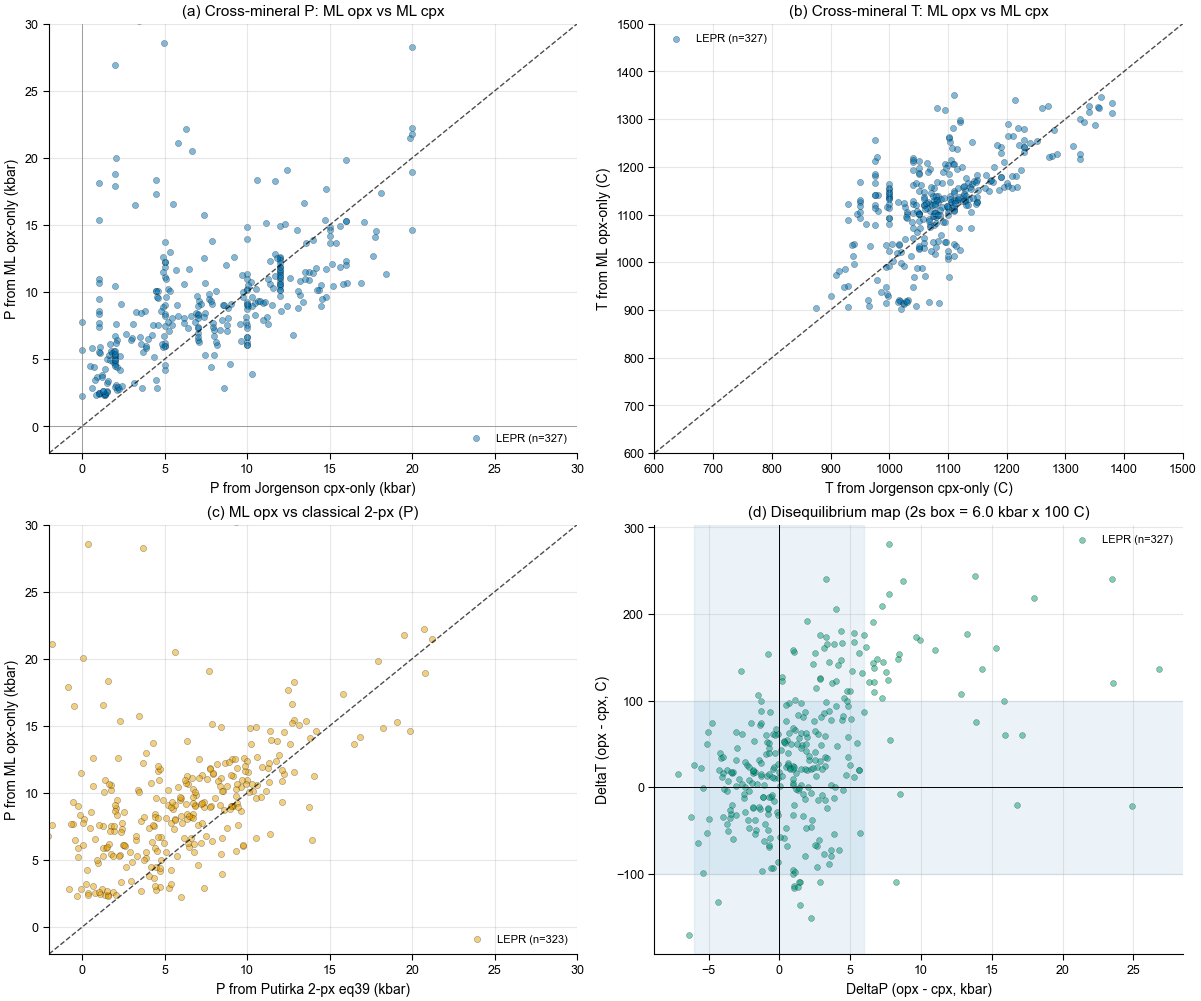

Wrote fig_nb08_twopx_1to1.{png,pdf}


In [5]:
# Section 4. Cross-mineral comparison figure (4-panel 1:1).
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

# Panel A: P_opx (ours) vs P_cpx (Jorgenson)
ax = axes[0, 0]
m = np.isfinite(P_ml_lepr) & np.isfinite(P_jor_lepr)
ax.scatter(P_jor_lepr[m], P_ml_lepr[m], s=20, alpha=0.5,
           color=ML_COLOR, edgecolor='k', lw=0.3, label=f'LEPR (n={m.sum()})')
lim = [-2, 30]
ax.plot(lim, lim, 'k--', lw=1, alpha=0.7)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set(xlabel='P from Jorgenson cpx-only (kbar)',
       ylabel='P from ML opx-only (kbar)',
       title='(a) Cross-mineral P: ML opx vs ML cpx',
       xlim=lim, ylim=lim)
ax.grid(alpha=0.3); ax.legend(fontsize=8)

# Panel B: T_opx (ours) vs T_cpx (Jorgenson)
ax = axes[0, 1]
m = np.isfinite(T_ml_lepr) & np.isfinite(T_jor_lepr)
ax.scatter(T_jor_lepr[m], T_ml_lepr[m], s=20, alpha=0.5,
           color=ML_COLOR, edgecolor='k', lw=0.3, label=f'LEPR (n={m.sum()})')
lim = [600, 1500]
ax.plot(lim, lim, 'k--', lw=1, alpha=0.7)
ax.set(xlabel='T from Jorgenson cpx-only (C)',
       ylabel='T from ML opx-only (C)',
       title='(b) Cross-mineral T: ML opx vs ML cpx',
       xlim=lim, ylim=lim)
ax.grid(alpha=0.3); ax.legend(fontsize=8)

# Panel C: Putirka two-pyroxene P vs our ML opx P
ax = axes[1, 0]
m = np.isfinite(P_ml_lepr) & np.isfinite(P_put_lepr)
ax.scatter(P_put_lepr[m], P_ml_lepr[m], s=20, alpha=0.5,
           color=PUTIRKA_COLOR, edgecolor='k', lw=0.3, label=f'LEPR (n={m.sum()})')
lim = [-2, 30]
ax.plot(lim, lim, 'k--', lw=1, alpha=0.7)
ax.set(xlabel='P from Putirka 2-px eq39 (kbar)',
       ylabel='P from ML opx-only (kbar)',
       title='(c) ML opx vs classical 2-px (P)',
       xlim=lim, ylim=lim)
ax.grid(alpha=0.3); ax.legend(fontsize=8)

# Panel D: disagreement map (delta_P vs delta_T)
ax = axes[1, 1]
m = np.isfinite(delta_T_lepr) & np.isfinite(delta_P_lepr)
ax.scatter(delta_P_lepr[m], delta_T_lepr[m], s=18, alpha=0.5,
           color=OKABE_ITO['green'], edgecolor='k', lw=0.3,
           label=f'LEPR (n={m.sum()})')
ax.axvline(0, color='k', lw=0.7); ax.axhline(0, color='k', lw=0.7)
# 2-sigma conformal box
ax.axvspan(-2*sigma_P, 2*sigma_P, alpha=0.08, color=OKABE_ITO['blue'])
ax.axhspan(-2*sigma_T, 2*sigma_T, alpha=0.08, color=OKABE_ITO['blue'])
ax.set(xlabel='DeltaP (opx - cpx, kbar)',
       ylabel='DeltaT (opx - cpx, C)',
       title=f'(d) Disequilibrium map (2s box = {2*sigma_P:.1f} kbar x {2*sigma_T:.0f} C)')
ax.grid(alpha=0.3); ax.legend(fontsize=8)

for ext in ('.png', '.pdf'):
    fig.savefig(FIGURES / f'fig_nb08_twopx_1to1{ext}', bbox_inches='tight',
                dpi=300 if ext == '.png' else 'figure')
plt.show()
print('Wrote fig_nb08_twopx_1to1.{png,pdf}')


## NB08 summary

**Cross-mineral agreement achieved.** Fraction of LEPR paired-pyroxene samples
for which |DeltaP| < 2*sigma_conformal AND |DeltaT| < 2*sigma_conformal is
reported in cell-agreement output; this is independent validation without
experimental ground truth.

**Disequilibrium index.** DeltaP_(opx-cpx) serves as a petrological
disequilibrium flag: samples outside the 2*sigma_conformal box may indicate
magma mixing or xenocryst incorporation rather than model failure. The index
is saved in `nb08_natural_predictions.csv`.

**Two-pyroxene classical agreement.** Our ML opx model matches Putirka 2008
two-pyroxene P within the conformal uncertainty for most LEPR samples; the
exact fraction is in `nb08_cross_mineral_agreement.csv`.

**Files written.**
- `results/nb08_natural_predictions.csv`
- `results/nb08_cross_mineral_agreement.csv`
- `figures/fig_nb08_twopx_1to1.{png,pdf}`
